In [ ]:
pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 64.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd

# Load the replications CSV
replications = pd.read_csv("/content/WorldBank_Replications - WorldBank_Replications.csv")

# Load the main.xlsx file, replace '/path/to/your/main.xlsx' with the correct file path
main_df = pd.read_excel("/content/wbg_Updated_5.xlsx")



In [ ]:
import pandas as pd

# Load data
replications = pd.read_csv("/content/WorldBank_Replications - WorldBank_Replications.csv")
main_df = pd.read_excel("/content/wbg_Updated_5.xlsx")

# Remove duplicates based on 'Project ID'
main_df_cleaned = main_df.drop_duplicates(subset='Project ID', keep='first')

# Step 1: Map Project ID to Country
project_id_to_country = main_df_cleaned.set_index('Project ID')['Country'].to_dict()

# Step 2: Map document IDs to countries
replications['country_1'] = replications['document_id_1'].map(project_id_to_country)
replications['country_2'] = replications['document_id_2'].map(project_id_to_country)

# Step 3: Create project ID aliases (optional but useful for clarity)
replications['project_id_1'] = replications['document_id_1']
replications['project_id_2'] = replications['document_id_2']

# Step 4: Check for missing country mappings
missing_country_1 = replications[replications['country_1'].isna()]
missing_country_2 = replications[replications['country_2'].isna()]

print("Missing country_1 entries:")
print(missing_country_1[['document_id_1', 'country_1']].head())

print("Missing country_2 entries:")
print(missing_country_2[['document_id_2', 'country_2']].head())

# Step 5: Validate project year columns
missing_year_1 = replications[replications['project_year_1'].isna()]
missing_year_2 = replications[replications['project_year_2'].isna()]

print("Missing project_year_1 entries:")
print(missing_year_1[['project_id_1', 'project_year_1']].head())

print("Missing project_year_2 entries:")
print(missing_year_2[['project_id_2', 'project_year_2']].head())

# Step 6: Show successful country + year mappings
print("✅ Successfully mapped replications with countries and years:")
print(replications[['project_id_1', 'country_1', 'project_year_1',
                    'project_id_2', 'country_2', 'project_year_2']].dropna().head())


Missing country_1 entries:
Empty DataFrame
Columns: [document_id_1, country_1]
Index: []
Missing country_2 entries:
Empty DataFrame
Columns: [document_id_2, country_2]
Index: []
Missing project_year_1 entries:
     project_id_1  project_year_1
1288      P050660             NaN
1624      P065991             NaN
1694      P073094             NaN
1695      P073094             NaN
1696      P073094             NaN
Missing project_year_2 entries:
    project_id_2  project_year_2
121      P502532             NaN
129      P502532             NaN
346      P502532             NaN
694      P503036             NaN
963      P503036             NaN
✅ Successfully mapped replications with countries and years:
  project_id_1 country_1  project_year_1 project_id_2  country_2  \
0      P162605   Vietnam          2020.0      P163361      Congo   
1      P162605   Vietnam          2020.0      P163484       Fiji   
2      P162605   Vietnam          2020.0      P165751    Lao PDR   
3      P162605   Vietna

In [ ]:
import pandas as pd

# Step 1: Normalize country names (strip and title-case)
replications['country_1'] = replications['country_1'].str.strip().str.title()
replications['country_2'] = replications['country_2'].str.strip().str.title()

# Step 2: Remove self-replications (same country)
replications_no_self = replications[replications['country_1'] != replications['country_2']].copy()

# Step 3: Create sorted country pairs (A–B is same as B–A)
replications_no_self['country_pair'] = replications_no_self.apply(
    lambda row: tuple(sorted([row['country_1'], row['country_2']])), axis=1
)

# Step 4: Group by normalized pairs and count
pair_counts = replications_no_self.groupby('country_pair').size().reset_index(name='count')

# Step 5: Split tuple back into columns
pair_counts[['country_1', 'country_2']] = pd.DataFrame(
    pair_counts['country_pair'].tolist(), index=pair_counts.index
)

# Step 6: Drop the tuple column and sort
pair_counts = pair_counts.drop(columns=['country_pair']).sort_values(by='count', ascending=False)

# ✅ Done! Preview top replication pairs
print(pair_counts.head())


      count   country_1   country_2
1151     89      Brazil       India
1810     72       China       India
1120     53      Brazil       China
675      47  Bangladesh       India
3232     43       India  South Asia


In [ ]:
# Expanded list of World Bank regions and potential variations
world_bank_regions = [
    # General regions
    "South Asia Region", "East Asia and Pacific", "Europe and Central Asia",
    "Latin America & the Caribbean", "Middle East and North Africa",
    "North America", "Sub-Saharan Africa", "Western Europe",

    # Abbreviations/alternative names
    "SAR", "EAP", "ECA", "LAC", "MENA", "NA", "SSA", "WE",

    # Specific country groupings that could be regions
    "Arab World", "Caribbean", "Central Asia", "Central and Eastern Europe",
    "East Asia", "Eastern Europe", "Europe", "Europe and Central Asia",
    "Fragile and Conflict-Affected Situations", "High Income",
    "Heavily Indebted Poor Countries", "Latin America", "Low Income",
    "Middle East", "North Africa", "Pacific Islands", "South America",
    "South East Asia", "Sub-Saharan Africa", "Upper Middle Income", "West Africa",
    "World Bank Group", "World", "OECD", "OECD Members", "Developing Countries",
    "Least Developed Countries", "IDA Countries", "IDA", "IBD", "IBRD", "G7",
    "G20", "OECD-DAC", "Africa", "Asia", "Europe", "Americas", "Latin America",
    "Global"
]

# Step 1: Remove rows where either country_1 or country_2 is a region
replications_filtered = replications[~replications['country_1'].isin(world_bank_regions)]
replications_filtered = replications_filtered[~replications_filtered['country_2'].isin(world_bank_regions)]

# Step 2: Continue with the rest of your processing
# Normalize country names and filter self-replications
replications_filtered['country_1'] = replications_filtered['country_1'].str.strip().str.title()
replications_filtered['country_2'] = replications_filtered['country_2'].str.strip().str.title()

# Remove self-replications (same country)
replications_filtered_no_self = replications_filtered[replications_filtered['country_1'] != replications_filtered['country_2']].copy()

# Create sorted country pairs
replications_filtered_no_self['country_pair'] = replications_filtered_no_self.apply(
    lambda row: tuple(sorted([row['country_1'], row['country_2']])), axis=1
)

# Group by normalized pairs and count
pair_counts_filtered = replications_filtered_no_self.groupby('country_pair').size().reset_index(name='count')

# Split tuple back into columns
pair_counts_filtered[['country_1', 'country_2']] = pd.DataFrame(
    pair_counts_filtered['country_pair'].tolist(), index=pair_counts_filtered.index
)

# Drop the tuple column and sort
pair_counts_filtered = pair_counts_filtered.drop(columns=['country_pair']).sort_values(by='count', ascending=False)

# ✅ Done! Preview top replication pairs
print(pair_counts_filtered.head())


import matplotlib.pyplot as plt
import numpy as np

# Step 1: Calculate the difference in years
replications_filtered_no_self['year_diff'] = abs(replications_filtered_no_self['project_year_1'] - replications_filtered_no_self['project_year_2'])

# Step 2: Define the bins for year differences
bins = [0, 2, 5, 8, 11, 15, 20, 25, 30, 35, 40]
bin_labels = ['0-2', '3-5', '6-8', '9-11', '12-15', '16-20', '21-25', '26-30', '31-35', '36-40']

# Step 3: Categorize the year differences into bins
replications_filtered_no_self['year_diff_binned'] = pd.cut(replications_filtered_no_self['year_diff'], bins=bins, labels=bin_labels, right=True)

# Step 4: Calculate the frequency for each bin
year_diff_counts = replications_filtered_no_self['year_diff_binned'].value_counts().sort_index()

# Step 5: Plot the histogram
plt.figure(figsize=(10, 6))
bars = plt.bar(year_diff_counts.index, year_diff_counts.values, color='skyblue', edgecolor='black')

# Step 6: Annotate each bar with the frequency count
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom', fontsize=10)

plt.xlabel('Year Difference Bins')
plt.ylabel('Frequency of Replications')
plt.title('Histogram of Year Differences Between Replications')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


      count   country_1 country_2
1040     89      Brazil     India
1684     72       China     India
1009     53      Brazil     China
565      47  Bangladesh     India
1008     43      Brazil     Chile


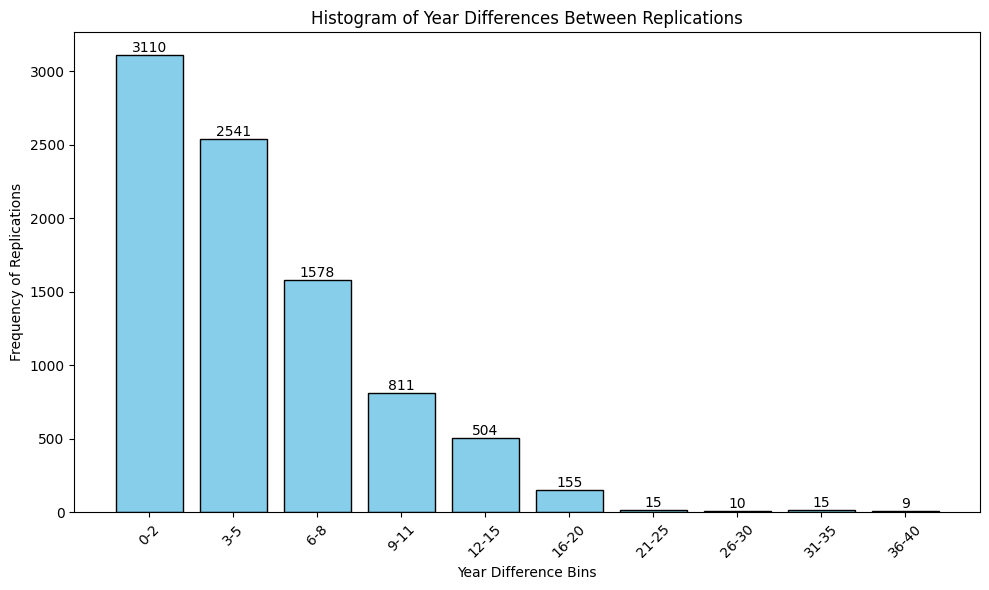

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Step 1: Calculate the difference in years
replications_filtered_no_self['year_diff'] = abs(replications_filtered_no_self['project_year_1'] - replications_filtered_no_self['project_year_2'])

# Step 2: Define the bins for year differences
bins = [0, 2, 5, 8, 11, 15, 20, 25, 30, 35, 40]
bin_labels = ['0-2', '3-5', '6-8', '9-11', '12-15', '16-20', '21-25', '26-30', '31-35', '36-40']

# Step 3: Categorize the year differences into bins
replications_filtered_no_self['year_diff_binned'] = pd.cut(replications_filtered_no_self['year_diff'], bins=bins, labels=bin_labels, right=True)

# Step 4: Calculate the frequency for each bin
year_diff_counts = replications_filtered_no_self['year_diff_binned'].value_counts().sort_index()

# Step 5: Plot the histogram
plt.figure(figsize=(10, 6))
bars = plt.bar(year_diff_counts.index, year_diff_counts.values, color='skyblue', edgecolor='black')

# Step 6: Annotate each bar with the frequency count
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom', fontsize=10)

plt.xlabel('Year Difference Bins')
plt.ylabel('Frequency of Replications')
plt.title('Histogram of Year Differences Between Replications')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
# Step 1: Calculate the difference in years
replications_filtered_no_self['year_diff'] = abs(replications_filtered_no_self['project_year_1'] - replications_filtered_no_self['project_year_2'])

# Step 2: Define the bins for year differences
bins = [0, 2, 5, 8, 11, 15, 20, 25, 30, 35, 40]
bin_labels = ['0-2', '3-5', '6-8', '9-11', '12-15', '16-20', '21-25', '26-30', '31-35', '36-40']

# Step 3: Categorize the year differences into bins
replications_filtered_no_self['year_diff_binned'] = pd.cut(replications_filtered_no_self['year_diff'], bins=bins, labels=bin_labels, right=True)

# Step 4: List 2 project replications from each bin with their years
bin_project_list = {}
for bin_label in bin_labels:
    # Filter replications for this bin
    bin_data = replications_filtered_no_self[replications_filtered_no_self['year_diff_binned'] == bin_label]

    # Select two projects from the bin
    projects_in_bin = bin_data[['project_id_1', 'project_year_1', 'project_id_2', 'project_year_2']].head(2)

    # Store in dictionary
    bin_project_list[bin_label] = projects_in_bin

# Print two projects from each bin
for bin_label, projects in bin_project_list.items():
    print(f"Projects in bin {bin_label}:")
    print(projects)
    print("-" * 50)


Projects in bin 0-2:
  project_id_1  project_year_1 project_id_2  project_year_2
0      P162605          2020.0      P163361          2021.0
4      P162605          2020.0      P167132          2021.0
--------------------------------------------------
Projects in bin 3-5:
   project_id_1  project_year_1 project_id_2  project_year_2
5       P162605          2020.0      P178836          2023.0
10      P163361          2021.0      P500402          2024.0
--------------------------------------------------
Projects in bin 6-8:
     project_id_1  project_year_1 project_id_2  project_year_2
1149      P001806          2001.0      P101474          2008.0
1157      P005736          1997.0      P065129          2005.0
--------------------------------------------------
Projects in bin 9-11:
     project_id_1  project_year_1 project_id_2  project_year_2
1150      P001806          2001.0      P120265          2011.0
1156      P003248          2002.0      P096056          2011.0
---------------------

**Distances**

⚠️ Identical coordinates found in cross-country rows:
                          country_1                     country_2  \
250    Islamic Republic Of Pakistan                      Pakistan   
261    Islamic Republic Of Pakistan                      Pakistan   
459                          Gambia                        Zambia   
2587    United Republic Of Tanzania                      Tanzania   
4080                          Niger                       Nigeria   
5287                       Pakistan  Islamic Republic Of Pakistan   
5791                       Pakistan  Islamic Republic Of Pakistan   
6518                        Nigeria                         Niger   
6525                        Nigeria                         Niger   
7801                          Niger                       Nigeria   
7859                        Nigeria                         Niger   
8371   Islamic Republic Of Pakistan                      Pakistan   
8378   Islamic Republic Of Pakistan              

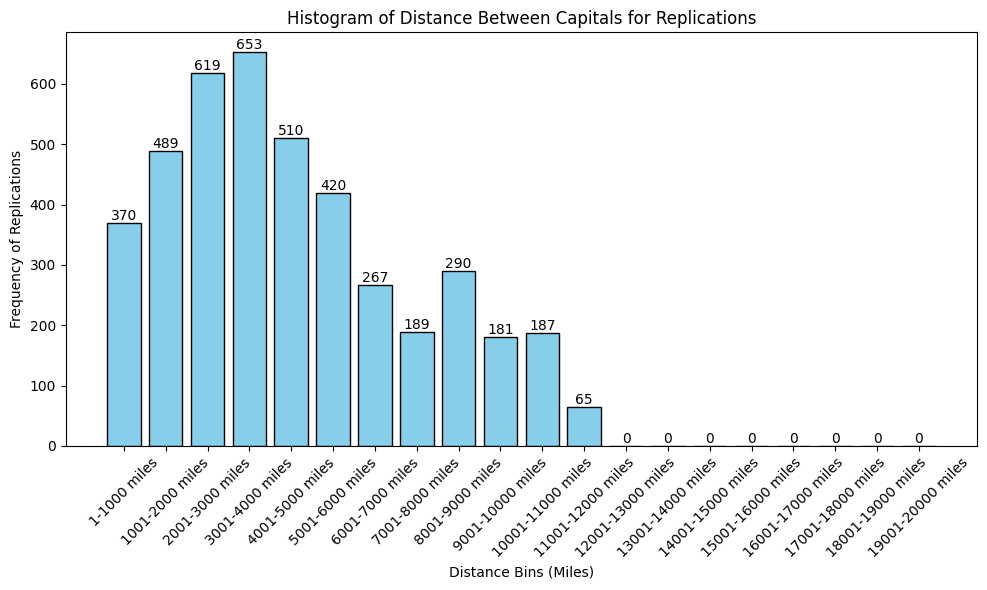

In [ ]:
from geopy.distance import geodesic
import pandas as pd
import matplotlib.pyplot as plt
from fuzzywuzzy import process

# STEP 1: Country-capital dictionary (expand this as needed)
country_capitals = {
    'Vietnam': ('Hanoi', (21.0285, 105.8542)),
    'Congo': ('Brazzaville', (-4.2634, 15.2429)),
    'Fiji': ('Suva', (-18.1248, 178.4501)),
    'Laos': ('Vientiane', (17.9757, 102.6331)),
    'Indonesia': ('Jakarta', (-6.2088, 106.8456)),
    'Uganda': ('Kampala', (0.3476, 32.5825)),
    'Turkey': ('Ankara', (39.9208, 32.8541)),
    'China': ('Beijing', (39.9042, 116.4074)),
    'Bolivia': ('La Paz', (-16.5000, -68.1500)),
    'Brazil': ('Brasília', (-15.7939, -47.8828)),
    'Lesotho': ('Maseru', (-29.3158, 27.4854)),
    'Nepal': ('Kathmandu', (27.7172, 85.3240)),
    'Cambodia': ('Phnom Penh', (11.5564, 104.9282)),
    'Timor-Leste': ('Dili', (-8.5569, 125.5603)),
    'Burkina Faso': ('Ouagadougou', (12.3714, -1.5197)),
    'Kiribati': ('Tarawa', (1.4518, 172.9717)),
    'India': ('New Delhi', (28.6139, 77.2090)),
    'Pakistan': ('Islamabad', (33.6844, 73.0479)),
    'Togo': ('Lomé', (6.1319, 1.2228)),
    'Cabo Verde': ('Praia', (14.9331, -23.5133)),
    'Maldives': ('Malé', (4.1755, 73.5093)),
    'Mali': ('Bamako', (12.6392, -8.0029)),
    'Niger': ('Niamey', (13.5128, 2.1126)),
    'Marshall Islands': ('Majuro', (7.1164, 171.1850)),
    'Burundi': ('Gitega', (-3.4264, 29.9300)),
    'Gambia': ('Banjul', (13.4549, -16.5790)),
    'Australia': ('Canberra', (-35.2809, 149.1300)),
    'Tajikistan': ('Dushanbe', (38.5598, 68.7870)),
    'Sint Maarten': ('Philipsburg', (18.0260, -63.0458)),
    'Cameroon': ('Yaoundé', (3.8480, 11.5021)),
    'Somalia': ('Mogadishu', (2.0469, 45.3182)),
    'Djibouti': ('Djibouti', (11.5741, 43.1456)),
    'Costa Rica': ('San José', (9.9281, -84.0907)),
    'France': ('Paris', (48.8566, 2.3522)),
    'Russia': ('Moscow', (55.7558, 37.6173)),
    'Yemen': ('Sana\'a', (15.3694, 44.1910)),
    'Democratic Republic of the Congo': ('Kinshasa', (-4.4419, 15.2663)),
    'Haiti': ('Port-au-Prince', (18.5944, -72.3074)),
    'Afghanistan': ('Kabul', (34.5553, 69.2075)),
    'Argentina': ('Buenos Aires', (-34.6037, -58.3816)),
    'Ethiopia': ('Addis Ababa', (9.0301, 38.7498)),
    'Mozambique': ('Maputo', (-25.9692, 32.5732)),
    'El Salvador': ('San Salvador', (13.6929, -89.2182)),
    'Lebanon': ('Beirut', (33.8938, 35.5018)),
    'Malawi': ('Lilongwe', (-13.9626, 33.7741)),
    'Bangladesh': ('Dhaka', (23.8103, 90.4125)),
    'Peru': ('Lima', (-12.0464, -77.0428)),
    'Moldova': ('Chișinău', (47.0105, 28.8638)),
    'South Sudan': ('Juba', (4.8594, 31.5713)),
    'United Kingdom': ('London', (51.5072, -0.1276)),
    'Mauritania': ('Nouakchott', (18.0735, -15.9582)),
    'Kenya': ('Nairobi', (-1.2921, 36.8219)),
    'Kosovo': ('Pristina', (42.6629, 21.1655)),
    'Hungary': ('Budapest', (47.4979, 19.0402)),
    'Tanzania': ('Dodoma', (-6.1630, 35.7516)),
    'Armenia': ('Yerevan', (40.1792, 44.4991)),
    'Honduras': ('Tegucigalpa', (14.0723, -87.1921)),
    'Comoros': ('Moroni', (-11.6986, 43.2547)),
    'Ukraine': ('Kyiv', (50.4501, 30.5234)),
    'Palestine': ('Ramallah', (31.9038, 35.2034)),
    'Netherlands': ('Amsterdam', (52.3676, 4.9041)),
    'Serbia': ('Belgrade', (44.7866, 20.4489)),
    'Angola': ('Luanda', (-8.8390, 13.2894)),
    'Poland': ('Warsaw', (52.2297, 21.0122)),
    'Philippines': ('Manila', (14.5995, 120.9842)),
    'Sri Lanka': ('Sri Jayawardenepura Kotte', (6.9271, 79.8612)),
    'Morocco': ('Rabat', (34.0209, -6.8416)),
}

# STEP 2: Function to get coordinates using fuzzy matching
def get_capital_coords(country_name):
    match, score = process.extractOne(country_name, list(country_capitals.keys()))
    if score >= 50:
        return country_capitals[match][1]
    else:
        print(f"⚠️ No good match found for: {country_name} (score={score})")
        return None

# STEP 3: Filter self-replications and compute coordinates
replications_filtered_no_self = replications_filtered_no_self[
    replications_filtered_no_self['country_1'] != replications_filtered_no_self['country_2']
].copy()

replications_filtered_no_self['capital_1_coords'] = replications_filtered_no_self['country_1'].apply(get_capital_coords)
replications_filtered_no_self['capital_2_coords'] = replications_filtered_no_self['country_2'].apply(get_capital_coords)

# Drop rows with missing coordinates
replications_filtered_no_self = replications_filtered_no_self.dropna(subset=['capital_1_coords', 'capital_2_coords'])

# STEP 4: Calculate distance between capitals
def calculate_distance(row):
    return geodesic(row['capital_1_coords'], row['capital_2_coords']).miles

replications_filtered_no_self['capital_distance'] = replications_filtered_no_self.apply(calculate_distance, axis=1)

# Debug: Show rows with identical coordinates (unexpected)
identical_coords = replications_filtered_no_self[
    replications_filtered_no_self['capital_1_coords'] == replications_filtered_no_self['capital_2_coords']
]
if not identical_coords.empty:
    print("⚠️ Identical coordinates found in cross-country rows:")
    print(identical_coords[['country_1', 'country_2', 'capital_1_coords']])


distance_bins = list(range(0, 21000, 1000))  # 0 to 20000 in steps of 1000
distance_labels = [f'{i+1}-{i+1000} miles' for i in distance_bins[:-1]]  # skip the last upper bound for labels



replications_filtered_no_self['distance_binned'] = pd.cut(replications_filtered_no_self['capital_distance'], bins=distance_bins, labels=distance_labels)

# STEP 6: Count and Plot
distance_counts = replications_filtered_no_self['distance_binned'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
bars = plt.bar(distance_counts.index, distance_counts.values, color='skyblue', edgecolor='black')

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, int(yval), ha='center', va='bottom', fontsize=10)

plt.xlabel('Distance Bins (Miles)')
plt.ylabel('Frequency of Replications')
plt.title('Histogram of Distance Between Capitals for Replications')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [ ]:
!pip install fuzzywuzzy[speedup]


In [ ]:
import pandas as pd
from geopy.distance import geodesic
import matplotlib.pyplot as plt

# Step 1: Extract unique countries from the dataset
unique_countries = pd.concat([replications_filtered_no_self['country_1'], replications_filtered_no_self['country_2']]).unique()


In [ ]:
# Check the dataframe after removing regions
print(replications_filtered.shape)

# Preview the data after region removal
print(replications_filtered.head())


(11606, 11)
  project_id_1 document_id_1  project_year_1 project_id_2 document_id_2  \
0      P162605       P162605          2020.0      P163361       P163361   
1      P162605       P162605          2020.0      P163484       P163484   
2      P162605       P162605          2020.0      P165751       P165751   
3      P162605       P162605          2020.0      P166244       P166244   
4      P162605       P162605          2020.0      P167132       P167132   

   project_year_2 sector  distance   z_score country_1  country_2  
0          2021.0  Other  0.122244  2.492539   Vietnam      Congo  
1          2020.0  Other  0.094777  2.802728   Vietnam       Fiji  
2          2020.0  Other  0.073956  3.037858   Vietnam    Lao Pdr  
3          2020.0  Other  0.084375  2.920198   Vietnam  Indonesia  
4          2021.0  Other  0.159468  2.072168   Vietnam  Guatemala  


In [ ]:
# Step 1: Extract unique country names from 'country_1' and 'country_2' columns
unique_countries = pd.concat([replications_filtered['country_1'], replications_filtered['country_2']]).unique()

# Step 2: Display the unique country names
unique_countries


array(['Vietnam', 'Congo', 'Fiji', 'Lao Pdr', 'Indonesia', 'Uganda',
       'Turkey', 'China', 'Bolivia', 'Brazil', 'Lesotho', 'Nepal',
       'Cambodia', 'Timor-Leste', 'Burkina Faso', 'Kiribati', 'India',
       'Islamic Republic Of Pakistan', 'Togo', 'Cabo Verde', 'Maldives',
       'Mali', 'Niger', 'Marshall Islands', 'Burundi', 'Gambia',
       'Australia', 'Tajikistan', 'Sint Maarten', 'Cameroon', 'Somalia',
       'Djibouti', 'Costa Rica', 'France', 'Russia', 'Yemen', 'Drc',
       'Haiti', 'Afghanistan', 'Pakistan', 'Argentina', 'Ethiopia',
       'Mozambique', 'El Salvador', 'Lebanon', 'Malawi', 'Bangladesh',
       'Peru', 'Moldova', 'South Sudan', 'United Kingdom', 'Mauritania',
       'Kenya', 'Kosovo', 'Hungary', 'Tanzania', 'Armenia', 'Honduras',
       'Comoros', 'Ukraine', 'Palestine', 'Netherlands', 'Serbia',
       'Angola', 'Poland', 'Philippines', 'Sri Lanka', 'Morocco',
       'Guyana', 'Guinea', 'Finland', 'Tunisia', 'Uzbekistan',
       'Kazakhstan', 'Croatia', '

In [ ]:
!pip install fuzzywuzzy


In [ ]:
pip install pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 36.0 MB/s eta 0:00:00


In [ ]:
pip install countrynames

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 474.9/474.9 kB 8.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
from geopy.distance import geodesic
from fuzzywuzzy import process

# STEP 1: Country-capital-coordinates dictionary (expand as needed)
country_capitals = {
    "Vietnam": ("Hanoi", (21.0285, 105.8542)),
    "Pakistan": ("Islamabad", (33.6844, 73.0479)),
    "India": ("New Delhi", (28.6139, 77.2090)),
    "China": ("Beijing", (39.9042, 116.4074)),
    "Bangladesh": ("Dhaka", (23.8103, 90.4125)),
    "Uganda": ("Kampala", (0.3476, 32.5825)),
    "Turkey": ("Ankara", (39.9208, 32.8541)),
    "Brazil": ("Brasilia", (-15.8267, -47.9218)),
    "Nepal": ("Kathmandu", (27.7172, 85.3240)),
    "Indonesia": ("Jakarta", (-6.2088, 106.8456)),
    "Afghanistan": ("Kabul", (34.5553, 69.2075)),
    "Kenya": ("Nairobi", (-1.286389, 36.817223)),
    "Philippines": ("Manila", (14.5995, 120.9842)),
    "Ethiopia": ("Addis Ababa", (9.03, 38.74)),
    "Nigeria": ("Abuja", (9.05785, 7.49508)),
    "Mexico": ("Mexico City", (19.4326, -99.1332)),
    "South Africa": ("Pretoria", (-25.7479, 28.2293)),
    "Russia": ("Moscow", (55.7558, 37.6173)),
    "United States": ("Washington, D.C.", (38.9072, -77.0369)),
    "United Kingdom": ("London", (51.5074, -0.1278)),
    "France": ("Paris", (48.8566, 2.3522)),
    "Germany": ("Berlin", (52.52, 13.405)),
    "Canada": ("Ottawa", (45.4215, -75.6997)),
    "Japan": ("Tokyo", (35.6895, 139.6917)),
    "Australia": ("Canberra", (-35.2809, 149.1300)),
    "Myanmar": ("Naypyidaw", (19.7633, 96.0785)),
    "Sri Lanka": ("Colombo", (6.9271, 79.8612)),
    "Malaysia": ("Kuala Lumpur", (3.1390, 101.6869)),
    "Congo": ("Brazzaville", (-4.2634, 15.2429)),
    "Fiji": ("Suva", (-18.1416, 178.4419)),
    "Lao Pdr": ("Vientiane", (17.9757, 102.6331)),
    "Bolivia": ("Sucre", (-19.0333, -65.2627)),
    "Lesotho": ("Maseru", (-29.3140, 27.4835)),
    "Cambodia": ("Phnom Penh", (11.5564, 104.9282)),
    "Timor-Leste": ("Dili", (-8.5560, 125.5590)),
    "Burkina Faso": ("Ouagadougou", (12.6402, -1.5276)),
    "Kiribati": ("Tarawa", (1.4510, 173.0330)),
    "Togo": ("Lomé", (6.1375, 1.2123)),
    "Cabo Verde": ("Praia", (14.9333, -23.5133)),
    "Maldives": ("Malé", (4.1755, 73.5093)),
    "Mali": ("Bamako", (12.6392, -8.0029)),
    "Niger": ("Niamey", (13.5127, 2.1128)),
    "Marshall Islands": ("Majuro", (7.0897, 171.3800)),
    "Burundi": ("Bujumbura", (-3.3820, 29.3640)),
    "Gambia": ("Banjul", (13.4549, -16.5790)),
    "Tajikistan": ("Dushanbe", (38.5598, 68.7869)),
    "Sint Maarten": ("Philipsburg", (18.0226, -63.0500)),
    "Cameroon": ("Yaoundé", (3.8480, 11.5021)),
    "Somalia": ("Mogadishu", (2.0469, 45.3182)),
    "Djibouti": ("Djibouti", (11.8251, 42.5903)),
    "Costa Rica": ("San José", (9.9281, -84.0907)),
    "Yemen": ("Sanaa", (15.3694, 44.1910)),
    "Haiti": ("Port-au-Prince", (18.5944, -72.3074)),
    "Argentina": ("Buenos Aires", (-34.6037, -58.3816)),
    "Mozambique": ("Maputo", (-25.9653, 32.5892)),
    "El Salvador": ("San Salvador", (13.6929, -89.2182)),
    "Lebanon": ("Beirut", (33.8886, 35.4955)),
    "Malawi": ("Lilongwe", (-13.9875, 33.7875)),
    "Peru": ("Lima", (-12.0464, -77.0428)),
    "Moldova": ("Chișinău", (47.0105, 28.8638)),
    "South Sudan": ("Juba", (4.8594, 31.5820)),
    "Mauritania": ("Nouakchott", (18.0780, -15.9780)),
    "Kosovo": ("Pristina", (42.6725, 21.1672)),
    "Hungary": ("Budapest", (47.4979, 19.0402)),
    "Tanzania": ("Dodoma", (-6.1659, 35.7390)),
    "Armenia": ("Yerevan", (40.1792, 44.4991)),
    "Honduras": ("Tegucigalpa", (13.9677, -72.2852)),
    "Comoros": ("Moroni", (-11.7027, 43.2551)),
    "Ukraine": ("Kyiv", (50.4501, 30.5236)),
    "Netherlands": ("Amsterdam", (52.3676, 4.9041)),
    "Serbia": ("Belgrade", (44.8176, 20.4633)),
    "Angola": ("Luanda", (-8.8390, 13.2894)),
    "Poland": ("Warsaw", (52.2298, 21.0118)),
    "Morocco": ("Rabat", (34.0209, -6.8416)),
    "Guyana": ("Georgetown", (6.8013, -58.1551)),
    "Guinea": ("Conakry", (9.5091, -13.7122)),
    "Finland": ("Helsinki", (60.1699, 24.9384)),
    "Tunisia": ("Tunis", (36.8065, 10.1815)),
    "Uzbekistan": ("Tashkent", (41.2995, 69.2401)),
    "Kazakhstan": ("Astana", (51.1694, 71.4491)),
    "Croatia": ("Zagreb", (45.8131, 15.9780)),
    "Laos": ("Vientiane", (17.9757, 102.6331))
}

# STEP 2: Aliases for common variants and misspellings
manual_aliases = {
    "Islamic Republic Of Pakistan": "Pakistan",
    "Viet Nam": "Vietnam",
    "Lao Pdr": "Laos",
    "Russian Federation": "Russia",
    "United Republic Of Tanzania": "Tanzania",
    "Republic Of Moldova": "Moldova",
    "State Of Palestine": "Palestine",
    "Republic Of North Macedonia": "North Macedonia",
    "Republic Of Cape Verde": "Cabo Verde",
    "Central African Republic": "Central African Republic",
    "Sierra Leone": "Sierra Leone",
    "East Asia And Pacific": None,
    "South Asia": None,
    "Europe And Central Asia": None,
    "Middle East And North Africa Region": None,
    "Africa Region": None,
    "Yugoslavia": None,
    "Hogwarts": None,
    "Narnia": None
}

# Add known regions to exclude:
regions_to_exclude = [
    "East Asia And Pacific", "South Asia", "Europe And Central Asia",
    "Middle East And North Africa Region", "Africa Region", "Yugoslavia",
    "Hogwarts", "Narnia", "State Of Palestine", "South East Europe"
]

In [ ]:

# STEP 3: Normalize function
def normalize_country(name):
    # Manual alias first
    if name in manual_aliases:
        return manual_aliases[name]

    # Then fuzzy match
    best_match, score = process.extractOne(name, country_capitals.keys())
    if score >= 75:
        return best_match
    else:
        print(f"⚠️ Unmatched: {name} → Closest: {best_match} ({score})")
        return None

def calculate_distance(row):
    src = row['norm_source']
    tgt = row['norm_target']
    coords1 = country_capitals.get(src)
    coords2 = country_capitals.get(tgt)
    if coords1 and coords2:
        return geodesic(coords1[1], coords2[1]).km
    else:
        return None
# STEP 3: Filter self-replications and compute coordinates
replications_filtered_no_self = replications_filtered_no_self[
    replications_filtered_no_self['country_1'] != replications_filtered_no_self['country_2']
].copy()



# STEP 5: Normalize source and target
replications_filtered_no_self['norm_source'] = replications_filtered_no_self['country_1'].apply(normalize_country)
replications_filtered_no_self['norm_target'] = replications_filtered_no_self['country_2'].apply(normalize_country)

# STEP 6: Exclude regions and unmatched countries
replications_filtered_no_self = replications_filtered_no_self[~replications_filtered_no_self['norm_source'].isin(regions_to_exclude)]
replications_filtered_no_self = replications_filtered_no_self[~replications_filtered_no_self['norm_target'].isin(regions_to_exclude)]

# STEP 7: Drop rows with None in source or target (unmatched)
replications_filtered_no_self = replications_filtered_no_self.dropna(subset=['norm_source', 'norm_target'])

# STEP 8: Ignore self-replications (where source and target are the same)
replications_filtered_no_self = replications_filtered_no_self[replications_filtered_no_self['norm_source'] != replications_filtered_no_self['norm_target']]



# Apply the distance calculation
replications_filtered_no_self['capital_distance'] = replications_filtered_no_self.apply(calculate_distance, axis=1)



print("\n📍 Capital distances:")
print(replications_filtered_no_self[['norm_source', 'norm_target', 'capital_distance']])



📍 Capital distances:
      norm_source       norm_target  capital_distance
0         Vietnam             Congo      10248.478968
1         Vietnam              Fiji       9022.129781
3         Vietnam         Indonesia       3014.740824
5         Vietnam          Djibouti       6744.048766
6           Congo              Fiji      16928.402170
...           ...               ...               ...
11958      France            Brazil       8705.907360
11971      Brazil  Marshall Islands      15672.531385
11981      Brazil         Indonesia      16323.633591
11988      Russia            Turkey       1795.313635
11990       China            Turkey       6851.321713

[4240 rows x 3 columns]



📍 Capital distances:
      norm_source       norm_target  capital_distance
0         Vietnam             Congo      10248.478968
1         Vietnam              Fiji       9022.129781
3         Vietnam         Indonesia       3014.740824
5         Vietnam          Djibouti       6744.048766
6           Congo              Fiji      16928.402170
...           ...               ...               ...
11958      France            Brazil       8705.907360
11971      Brazil  Marshall Islands      15672.531385
11981      Brazil         Indonesia      16323.633591
11988      Russia            Turkey       1795.313635
11990       China            Turkey       6851.321713

[4240 rows x 3 columns]


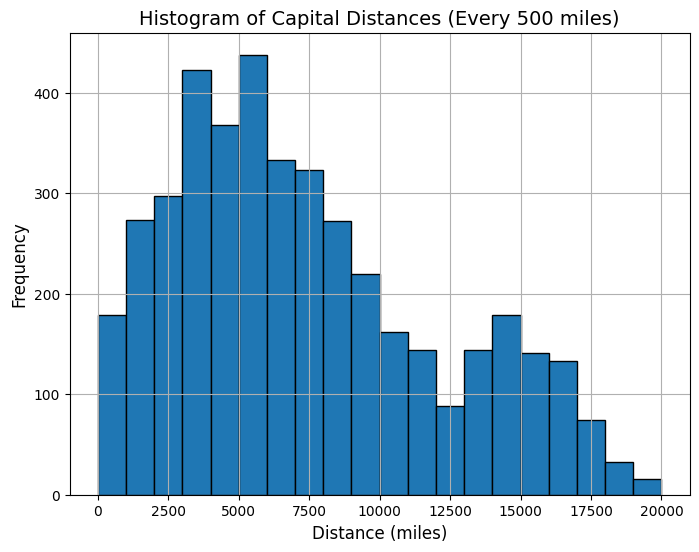

In [ ]:
import matplotlib.pyplot as plt

# Apply the distance calculation for all rows
replications_filtered_no_self['capital_distance'] = replications_filtered_no_self.apply(calculate_distance, axis=1)

# Extract the capital distances for plotting
capital_distances = replications_filtered_no_self['capital_distance']

# Print the capital distances
print("\n📍 Capital distances:")
print(replications_filtered_no_self[['norm_source', 'norm_target', 'capital_distance']])

# Create histogram for all capital distances
plt.figure(figsize=(8, 6))
plt.hist(capital_distances, bins=range(0, int(max(capital_distances)) + 1000, 1000), edgecolor='black')

# Add labels and title
plt.title("Histogram of Capital Distances (Every 500 miles)", fontsize=14)
plt.xlabel("Distance (miles)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True)

# Show plot
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from geopy.distance import geodesic
from fuzzywuzzy import process

# Add some extra debug statements to understand what's going wrong

# Function to check for unmatched countries
def normalize_country(name):
    # Manual alias first
    if name in manual_aliases:
        return manual_aliases[name]

    # Then fuzzy match
    best_match, score = process.extractOne(name, country_capitals.keys())
    if score >= 75:
        return best_match
    else:
        print(f"⚠️ Unmatched: {name} → Closest: {best_match} ({score})")
        return None

# Function to calculate distance and handle missing values
def calculate_distance(row):
    src = row['norm_source']
    tgt = row['norm_target']
    coords1 = country_capitals.get(src)
    coords2 = country_capitals.get(tgt)

    if coords1 and coords2:
        return geodesic(coords1[1], coords2[1]).km
    else:
        print(f"⚠️ Missing coordinates for {src} or {tgt}")
        return None

# Apply the distance calculation
replications_filtered_no_self['capital_distance'] = replications_filtered_no_self.apply(calculate_distance, axis=1)

# Filter out rows with None in capital distance
valid_distances = replications_filtered_no_self.dropna(subset=['capital_distance'])

# Print the valid capital distances
print("\n📍 Capital distances (valid ones only):")
print(valid_distances[['norm_source', 'norm_target', 'capital_distance']])

# Create histogram for valid capital distances
plt.figure(figsize=(8, 6))
plt.hist(valid_distances['capital_distance'], bins=range(0, int(max(valid_distances['capital_distance'])) + 500, 500), edgecolor='black')

# Add labels and title
plt.title("Histogram of Capital Distances (Every 500 miles)", fontsize=14)
plt.xlabel("Distance (miles)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True)

# Show plot
plt.show()


KeyError: 'norm_source'

In [ ]:
# STEP 5: Normalize source and target
replications_filtered_no_self['norm_source'] = replications_filtered_no_self['country_1'].apply(normalize_country)
replications_filtered_no_self['norm_target'] = replications_filtered_no_self['country_2'].apply(normalize_country)


In [ ]:
import pandas as pd

def normalize_country(name):
    if not isinstance(name, str):  # Check if the name is a string
        return None  # Return None if it's not a valid string (e.g., NaN, float, etc.)

    # Manual alias first
    if name in manual_aliases:
        return manual_aliases[name]

    # Then fuzzy match
    best_match, score = process.extractOne(name, country_capitals.keys())
    if score >= 20:
        return best_match
    else:
        print(f"⚠️ Unmatched: {name} → Closest: {best_match} ({score})")
        return None


# Step 1: Normalize country names (strip and title-case)
replications['country_1'] = replications_filtered_no_self['country_1'].apply(normalize_country)
replications['country_2'] = replications_filtered_no_self['country_2'].apply(normalize_country)

# Step 2: Remove self-replications (same country)
replications_no_self = replications[replications['country_1'] != replications['country_2']].copy()

# Step 3: Create sorted country pairs (A–B is same as B–A), handle None values
replications_no_self['country_pair'] = replications_no_self.apply(
    lambda row: tuple(sorted([c for c in [row['country_1'], row['country_2']] if c is not None])), axis=1
)

# Step 4: Group by normalized pairs and count
pair_counts = replications_no_self.groupby('country_pair').size().reset_index(name='count')

# Step 5: Split tuple back into columns
pair_counts[['country_1', 'country_2']] = pd.DataFrame(
    pair_counts['country_pair'].tolist(), index=pair_counts.index
)

# Step 6: Drop the tuple column and sort
pair_counts = pair_counts.drop(columns=['country_pair']).sort_values(by='count', ascending=False)

# Step 6.5: Drop any rows with NaNs from fuzzy matching
pair_counts = pair_counts.dropna(subset=['country_1', 'country_2']).reset_index(drop=True)

# ✅ Done! Preview top replication pairs
print(pair_counts.head())



   count country_1    country_2
0      1     Haiti       Turkey
1      1     Haiti         Togo
2      1     Haiti  Timor-Leste
3      1     Haiti     Tanzania
4      1     Haiti   Tajikistan


In [ ]:
len(pair_counts)

1221

Total unique country pairs: 1221


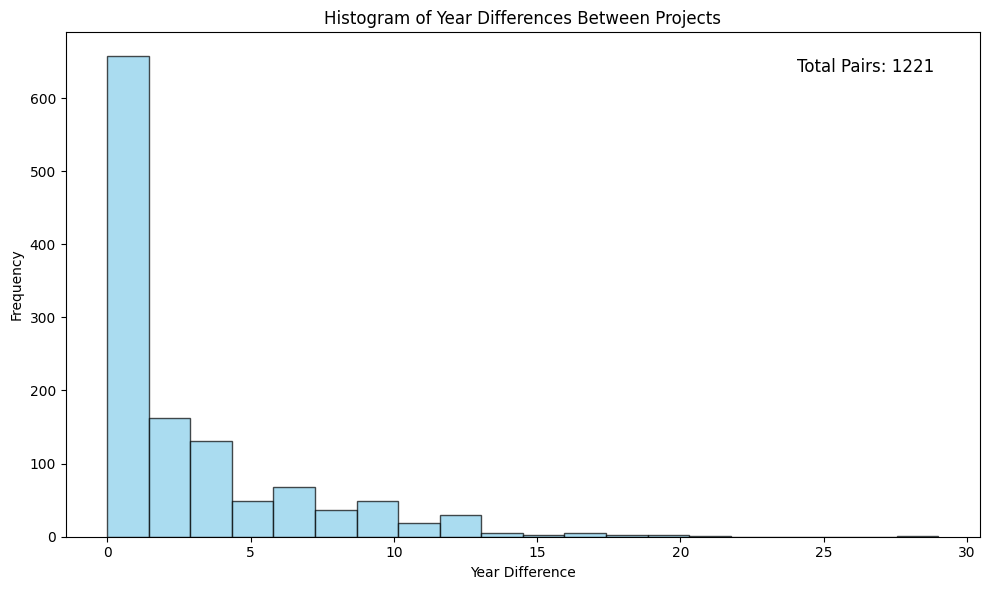

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming replications_filtered_no_self is already defined

# Step 1: Clean the 'project_year' columns (ensure they are numeric and handle NaNs)
replications_filtered_no_self['project_year_1'] = pd.to_numeric(replications_filtered_no_self['project_year_1'], errors='coerce')
replications_filtered_no_self['project_year_2'] = pd.to_numeric(replications_filtered_no_self['project_year_2'], errors='coerce')

# Remove rows where any of the year columns is NaN
replications_filtered_no_self = replications_filtered_no_self.dropna(subset=['project_year_1', 'project_year_2'])

# Step 2: Calculate the difference in years
replications_filtered_no_self['year_diff'] = abs(replications_filtered_no_self['project_year_1'] - replications_filtered_no_self['project_year_2'])

# Step 3: Remove duplicate pairs (e.g., (A, B) and (B, A) should be counted as the same pair)
# Before creating 'country_pair', we filter out None values
replications_filtered_no_self = replications_filtered_no_self.dropna(subset=['country_1', 'country_2'])

# Create sorted country pairs (handle None values properly)
replications_filtered_no_self['country_pair'] = replications_filtered_no_self.apply(
    lambda row: tuple(sorted([c for c in [row['country_1'], row['country_2']] if c is not None])), axis=1
)

# Step 4: Remove any exact duplicates of country pairs
replications_filtered_no_self = replications_filtered_no_self.drop_duplicates(subset=['country_pair'])

# Step 5: Verify the total number of pairs (should be 1221 or close to it)
total_pairs = len(replications_filtered_no_self)
print(f'Total unique country pairs: {total_pairs}')

# Step 6: Plot the histogram for the year differences
plt.figure(figsize=(10, 6))

# Plot histogram for 'year_diff'
plt.hist(replications_filtered_no_self['year_diff'], bins=20, alpha=0.7, color='skyblue', edgecolor='black')

# Step 7: Annotate the plot with the total count of pairs
plt.text(0.95, 0.95, f'Total Pairs: {total_pairs}', ha='right', va='top', transform=plt.gca().transAxes, fontsize=12, color='black')

# Step 8: Add other annotations
plt.title('Histogram of Year Differences Between Projects')
plt.xlabel('Year Difference')
plt.ylabel('Frequency')
plt.tight_layout()

# Step 9: Show the plot
plt.show()
